In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
pd.set_option('display.max_columns', None)

In [22]:
df = pd.read_csv(r'C:\Users\ACER\Desktop\Projects\Machine Learning Based Real Estate System\Dataset\Cleaned_Properties_V4.csv')

In [23]:
df.shape

(3632, 18)

In [24]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7502.0,2,2,2,3.0,New Property,1489.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,3,3,3,10.0,Relatively New,1081.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,3440.0,9,9,3,11.0,Relatively New,60.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5667.0,4,4,3+,1.0,Relatively New,3000.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,3,4,3+,6.0,New Property,1893.0,0,1,0,0,0,2,167


In [25]:
train_df = df.drop(columns=['society', 'price_per_sqft'])

In [26]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 77,1.00,2,2,2,3.0,New Property,1489.0,0,0,0,0,0,1,74
1,flat,sector 65,1.75,3,3,3,10.0,Relatively New,1081.0,0,1,0,0,0,0,124
2,house,sector 54,2.00,9,9,3,11.0,Relatively New,60.0,0,1,0,0,0,2,7
3,house,sector 108,1.70,4,4,3+,1.0,Relatively New,3000.0,0,0,0,0,0,1,0
4,flat,sector 81,2.30,3,4,3+,6.0,New Property,1893.0,0,1,0,0,0,2,167


### Luxury Score

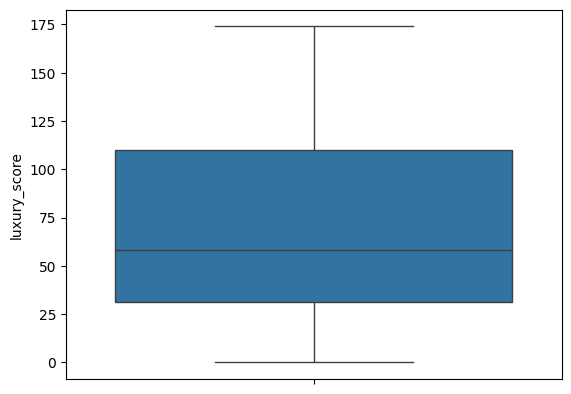

In [27]:
sns.boxplot(df['luxury_score'])
plt.show()

In [28]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return 'Low'
    elif 50 <= score < 150:
        return 'Medium'
    elif 150 <= score <= 175:
        return 'High'
    else:
        return None # or "Undefined" or any other label for scores outside the defined bins.

In [29]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [30]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 77,1.00,2,2,2,3.0,New Property,1489.0,0,0,0,0,0,1,74,Medium
1,flat,sector 65,1.75,3,3,3,10.0,Relatively New,1081.0,0,1,0,0,0,0,124,Medium
2,house,sector 54,2.00,9,9,3,11.0,Relatively New,60.0,0,1,0,0,0,2,7,Low
3,house,sector 108,1.70,4,4,3+,1.0,Relatively New,3000.0,0,0,0,0,0,1,0,Low
4,flat,sector 81,2.30,3,4,3+,6.0,New Property,1893.0,0,1,0,0,0,2,167,High


### floorNum

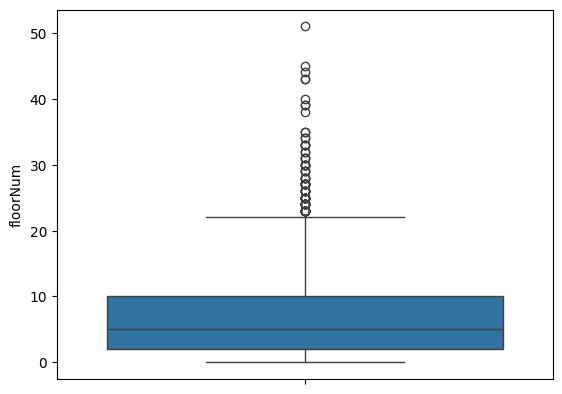

In [31]:
sns.boxplot(df['floorNum'])
plt.show()

In [32]:
def categorize_floor(score):
    if 0 <= score < 2:
        return 'Low Floor'
    elif 3 <= score < 10:
        return 'Med Floor'
    elif 11 <= score <= 51:
        return 'High Floor'
    else:
        return None # or "Undefined" or any other label for scores outside the defined bins.

In [33]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [34]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 77,1.00,2,2,2,3.0,New Property,1489.0,0,0,0,0,0,1,74,Medium,Med Floor
1,flat,sector 65,1.75,3,3,3,10.0,Relatively New,1081.0,0,1,0,0,0,0,124,Medium,None
2,house,sector 54,2.00,9,9,3,11.0,Relatively New,60.0,0,1,0,0,0,2,7,Low,High Floor
3,house,sector 108,1.70,4,4,3+,1.0,Relatively New,3000.0,0,0,0,0,0,1,0,Low,Low Floor
4,flat,sector 81,2.30,3,4,3+,6.0,New Property,1893.0,0,1,0,0,0,2,167,High,Med Floor


In [35]:
train_df.drop(columns=['floorNum', 'luxury_score'], inplace=True)

In [36]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 77,1.00,2,2,2,New Property,1489.0,0,0,0,0,0,1,Medium,Med Floor
1,flat,sector 65,1.75,3,3,3,Relatively New,1081.0,0,1,0,0,0,0,Medium,None
2,house,sector 54,2.00,9,9,3,Relatively New,60.0,0,1,0,0,0,2,Low,High Floor
3,house,sector 108,1.70,4,4,3+,Relatively New,3000.0,0,0,0,0,0,1,Low,Low Floor
4,flat,sector 81,2.30,3,4,3+,New Property,1893.0,0,1,0,0,0,2,High,Med Floor


### Converting all Categorical Columns to Numerical columns using Encoding

In [37]:
from sklearn.preprocessing import OrdinalEncoder

# Create a Copy of the original Data for Label Encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply Label Encoding to Categorical Columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the Dataset into Training and Testing Sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'manesar', 'sector 1', 'sector 102',
       'sector 103', 'sector 104', 'sector 105', 'sector 106',
       'sector 107', 'sector 108', 'sector 109', 'sector 10a',
       'sector 11', 'sector 110', 'sector 110a', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 18',
       'sector 2', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 55',
       'sector 56', 'sector 57', 'sector 58', 'sector

In [38]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,85.0,2,2,2.0,1.0,1489.0,0,0,0,0,0,1,2.0,2.0
1,0.0,71.0,3,3,3.0,3.0,1081.0,0,1,0,0,0,0,2.0,3.0
2,1.0,59.0,9,9,3.0,3.0,60.0,0,1,0,0,0,2,1.0,0.0
3,1.0,9.0,4,4,4.0,3.0,3000.0,0,0,0,0,0,1,1.0,1.0
4,0.0,90.0,3,4,4.0,1.0,1893.0,0,1,0,0,0,2,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3627,0.0,102.0,4,4,4.0,3.0,2726.0,0,1,0,1,0,1,2.0,0.0
3628,0.0,84.0,2,2,2.0,3.0,665.0,0,0,0,0,0,1,2.0,0.0
3629,1.0,12.0,5,4,1.0,3.0,2025.0,0,0,0,0,0,1,1.0,3.0
3630,0.0,4.0,4,5,4.0,1.0,2416.0,0,1,0,0,0,1,1.0,0.0


In [39]:
y_label

0       1.00
1       1.75
2       2.00
3       1.70
4       2.30
        ... 
3627    1.88
3628    0.75
3629    4.00
3630    2.00
3631    1.25
Name: price, Length: 3632, dtype: float64

### Technique 1: Correlation Analysis

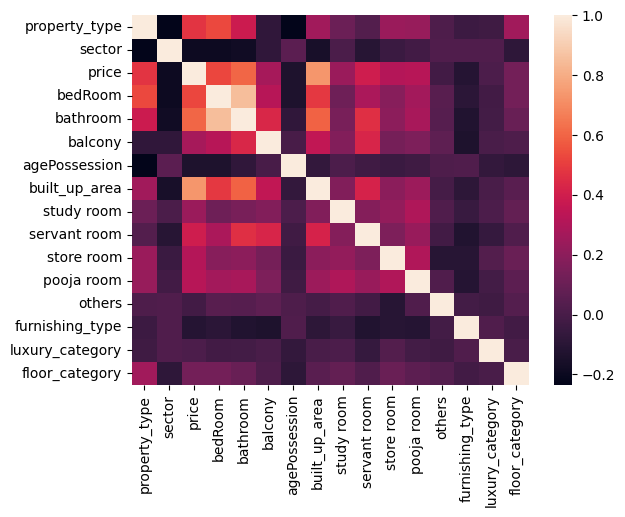

In [40]:
sns.heatmap(data_label_encoded.corr())
plt.show()

In [42]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature', 'price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.196824
1,price,1.000000
2,bedRoom,0.522262
3,bathroom,0.603204
4,balcony,0.271648
5,agePossession,-0.136273
6,built_up_area,0.731020
7,study room,0.241759
8,servant room,0.394283
9,store room,0.313166


### Technique 2: Random Forest Feature Importance

In [43]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest Regressor on Label Encoded Data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature Importance Scores for Label Encoded Data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.644213
0,property_type,0.102329
1,sector,0.097298
2,bedRoom,0.025727
3,bathroom,0.024977
8,servant room,0.021788
5,agePossession,0.016521
4,balcony,0.012902
9,store room,0.011836
14,floor_category,0.010608


### Technique 3: Gradient Boosting Feature Importances

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest Regressor on Label Encoded Data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature Importance Scores for Label Encoded Data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.680275
1,sector,0.105092
0,property_type,0.097705
3,bathroom,0.038912
8,servant room,0.026484
2,bedRoom,0.022886
9,store room,0.016765
5,agePossession,0.005283
7,study room,0.002116
12,furnishing_type,0.001435


### Technique 4: Permutation Importance

In [45]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest Regressor on Label Encoded Data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.900165
0,property_type,0.280035
1,sector,0.200761
8,servant room,0.047265
3,bathroom,0.040005
2,bedRoom,0.037771
5,agePossession,0.025306
9,store room,0.019652
4,balcony,0.018694
14,floor_category,0.013146


### Technique 5: LASSO

In [46]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO Regression Model
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract Coefficients
# Organize results into a DataFrame
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.418843
0,property_type,0.712063
3,bathroom,0.525178
9,store room,0.224030
8,servant room,0.179036
7,study room,0.178580
10,pooja room,0.098438
13,luxury_category,0.050532
14,floor_category,0.015081
4,balcony,-0.002858


### Technique 6: RFE